# Agent的基本使用

## 1、Agent中模型的传入

### 1.1 传入字符串

In [38]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain_tavily import TavilySearch
from rich import print as rprint
from langchain_core.tools import tool

model = ChatOpenAI(
    model="MiniMax-M3",
    api_key='sk-cp-GsTRU_GlFRX_WPY8cf8IqBTDtrVJP4zl4EWLZ8D7627lrDtV-MbWYnWWK7rmvT7ZRluuMtUL7VP2sCD2uq6SzkpIlY0EAJtCIHW2uSGAT4QKYxX9mJQmK8I',
    base_url="https://api.minimaxi.com/v1",
)

flag = 0

# 定义工具函数
@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    获取城市天气
    
    Args:
        city (str): 城市名称
    """
    # global flag
    # flag += 1
    
    # if flag < 3:
    #     return "TEMP_UNAVAILABLE: 抱歉，我无法获取天气信息。请稍后再试。"
    
    return f"{city}的天气是晴天"

@tool(parse_docstring=True)
def get_news(city: str, weather: str) -> str:
    """
    根据获取不同的天气获取城市不同的新闻
    
    Args:
        city (str): 城市名称
        weather (str): 天气情况
    """
    
    return f"{city}的新闻是{weather}的新闻"

web_search = TavilySearch(
    max_results=2,
    tavily_api_key="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",
)


agent = create_agent(
    model = model,
    tools = [get_weather, get_news, web_search],
    name = "evan-agent",
    system_prompt = """ 
    你是一个天气助手
    工作流程：
    1、理解用户的城市查询
    2、使用 get_weather 工具获取城市天气
    3、简介清晰地回答
    
    输出格式：
    - 天气情况
    - 温度
    - 注意事项（如有）
    """
)



In [39]:
res = agent.invoke({
    "messages": [
        {"role": "system", "content": "你是一个天气查询助手。用户会向你询问某个城市的天气情况，果然tools返回'TEMP_UNAVAILABLE:'开头的报错结果时，不要立即放弃，应该在调用同一个tool，最多重试三次，如果3次后仍然失败，再向用户说明服务不可用"} , 
        # {"role": "user", "content": "请帮我查询北京和上海的天气。再帮我查询应该去哪里旅游比较便宜？"}
        {"role": "user", "content": "请帮我查询北京的天气。有什么特殊的新闻吗？"}
        ]
}, config={"max_retries": 3, "retry_delay": 1})

rprint(res['messages'])

[
    SystemMessage(
        content="你是一个天气查询助手。用户会向你询问某个城市的天气情况，果然tools返回'TEMP_UNAVAILABLE:'开头的报错
结果时，不要立即放弃，应该在调用同一个tool，最多重试三次，如果3次后仍然失败，再向用户说明服务不可用",
        additional_kwargs={},
        response_metadata={},
        id='30f32086-6f61-4e5f-b242-d6b781604705'
    ),
    HumanMessage(
        content='请帮我查询北京的天气。有什么特殊的新闻吗？',
        additional_kwargs={},
        response_metadata={},
        id='f60a777a-74db-4720-8527-d83d711e5b05'
    ),
    AIMessage(
        content='<think>用户希望了解北京的天气以及与该天气相关的新闻。我需要先调用 get_weather 
获取天气信息，然后根据天气情况决定是否调用 get_news 
获取相关新闻。\n\n按照工作流程，先获取天气。</think>\n\n我来帮您查询北京的天气和相关新闻。',
        additional_kwargs={'refusal': None},
        response_metadata={
            'token_usage': {
                'completion_tokens': 79,
                'prompt_tokens': 2171,
                'total_tokens': 2250,
                'completion_tokens_details': {
                    'accepted_prediction_tokens': None,
                    'audio_tokens': None,
                    'reasoning_tokens': 40,
                    'rejected_prediction_tokens': None
                },
                'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 128},
                'total_characters': 0
            },
            'model_provider': 'openai',
            'model_name': 'MiniMax-M3',
            'system_fingerprint': None,
            'id': '06e875ed861b1c71526748fe2924da98',
            'service_tier': 'standard',
            'finish_reason': 'tool_calls',
            'logprobs': None
        },
        name='evan-agent',
        id='lc_run--01a066ad-6b14-7c22-bbcd-16150ff38f3a-0',
        tool_calls=[
            {
                'name': 'get_weather',
                'args': {'city': '北京'},
                'id': 'call_01a066ad7a0f7802bd41231c',
                'type': 'tool_call'
            }
        ],
        invalid_tool_calls=[],
        usage_metadata={
            'input_tokens': 2171,
            'output_tokens': 79,
            'total_tokens': 2250,
            'input_token_details': {'cache_read': 128},
            'output_token_details': {'reasoning': 40}
        }
    ),
    ToolMessage(
        content='北京的天气是晴天',
        name='get_weather',
        id='78543ec7-c03b-42d5-b756-4aeb3d56e8e6',
        tool_call_id='call_01a066ad7a0f7802bd41231c'
    ),
    AIMessage(
        content='<think>天气是晴天，接下来根据"晴天"获取北京的相关新闻。</think>\n\n',
        additional_kwargs={'refusal': None},
        response_metadata={
            'token_usage': {
                'completion_tokens': 51,
                'prompt_tokens': 2269,
                'total_tokens': 2320,
                'completion_tokens_details': {
                    'accepted_prediction_tokens': None,
                    'audio_tokens': None,
                    'reasoning_tokens': 13,
                    'rejected_prediction_tokens': None
                },
                'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 2171},
                'total_characters': 0
            },
            'model_provider': 'openai',
            'model_name': 'MiniMax-M3',
            'system_fingerprint': None,
            'id': '06e875f04e1a3e5b2756bcef7a992460',
            'service_tier': 'standard',
            'finish_reason': 'tool_calls',
            'logprobs': None
        },
        name='evan-agent',
        id='lc_run--01a066ad-7bad-77e3-b159-63195314415b-0',
        tool_calls=[
            {
                'name': 'get_news',
                'args': {'city': '北京', 'weather': '晴天'},
                'id': 'call_01a066ada13d7e019c6a2c45',
                'type': 'tool_call'
            }
        ],
        invalid_tool_calls=[],
        usage_metadata={
            'input_tokens': 2269,
            'output_tokens': 51,
            'total_tokens': 2320,
            'input_token_details': {'cache_read': 2171},
            'output_token_details': {'reasoning': 13}
        }
    ),
    ToolMessage(
        content='北京的新闻是晴天的新闻',
        nam

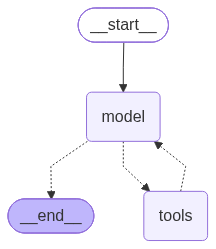

In [35]:
from IPython.display import display, Image

display(Image(agent.get_graph().draw_mermaid_png()))